In [1]:
# 正式写一个线性回归预测

In [3]:
%matplotlib inline

In [4]:
import random,torch
from d2l import torch as d2l

In [5]:
def synthetic_data(w,b,num_examples): #@save
    X = torch.normal(0,1,(num_examples,len(w)))  
    y = torch.matmul(X,w) + b  # 线性计算
    y += torch.normal(0,0.01,y.shape) 
    return X,y.reshape((-1,1))

In [ ]:
true_w = torch.tensor([2,-3.4])
true_b = 4.2
features,labels = synthetic_data(true_w,true_b,1000)

In [35]:
true_w.reshape(true_w.shape),true_w,true_w.shape,true_w.reshape(2)

(tensor([ 2.0000, -3.4000]),
 tensor([ 2.0000, -3.4000]),
 torch.Size([2]),
 tensor([ 2.0000, -3.4000]))

In [12]:
print("features:",features[0],"\nlabel",labels[0])

features: tensor([ 2.2529, -0.4040]) 
label tensor([10.0830])


In [16]:
labels[0]

tensor([10.0830])

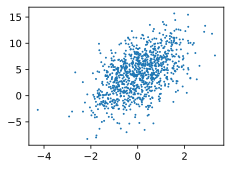

In [23]:
d2l.set_figsize()
d2l.plt.scatter(features[:,0].detach().numpy(),labels.detach().numpy(),1)

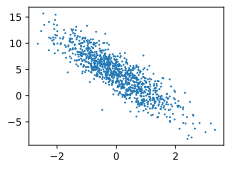

In [24]:
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1)

In [36]:
def data_iter(batch_size,features,labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)  # 打乱索引
    for i in range(0,num_examples,batch_size):
        batch_indices = torch.tensor(
            indices[i:min(i+batch_size,num_examples)]
        )
        yield features[batch_indices],labels[batch_indices]

In [38]:
batch_size = 10
for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[-1.3994,  0.8630],
        [ 0.3864,  0.7412],
        [-0.9421, -0.2264],
        [ 0.5280,  2.1140],
        [ 0.2227,  0.1103],
        [-0.8407, -0.6963],
        [-0.0221, -0.5719],
        [-0.0025,  0.7078],
        [-1.0283,  0.3342],
        [ 0.0832, -0.0529]]) 
 tensor([[-1.5227],
        [ 2.4595],
        [ 3.1035],
        [-1.9329],
        [ 4.2606],
        [ 4.8889],
        [ 6.1123],
        [ 1.7778],
        [ 1.0140],
        [ 4.5313]])


In [40]:
# 初始化超参
w = torch.normal(0,0.01,size=(2,1),requires_grad=True)
b = torch.zeros(1,requires_grad=True)

In [44]:
def linreg(X,w,b):  #@save
    return torch.matmul(X,w) + b

In [58]:
def squared_loss(y_hat,y):  #@save
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2  # 均方误差

In [62]:
def sgd(params,lr,batch_size):  #@save
    with torch.no_grad():  # 随机梯度下降
        for param in params:  
            param -= lr * param.grad / batch_size  #等级于 θ = θ - η * (∂L/∂θ)
            param.grad.zero_()

In [67]:
# 设置超参
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

In [71]:
for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l = loss(net(X,w,b),y)
        l.sum().backward()  # backward()只能对标量计算梯度
        sgd([w,b],lr,batch_size)
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(w,b)
        print(f'epoch{epoch+1},loss{float(train_l.mean()):f}')

tensor([[ 1.9997],
        [-3.4001]], requires_grad=True) tensor([4.2004], requires_grad=True)
epoch1,loss0.000049
tensor([[ 1.9999],
        [-3.3996]], requires_grad=True) tensor([4.2006], requires_grad=True)
epoch2,loss0.000050
tensor([[ 2.0000],
        [-3.3993]], requires_grad=True) tensor([4.2001], requires_grad=True)
epoch3,loss0.000050


In [72]:
print(f'w的估计误差:{true_w - w.reshape(true_w.shape)}')
print(f"b的估计误差:{true_b - b}")

w的估计误差:tensor([ 1.1683e-05, -7.0167e-04], grad_fn=<SubBackward0>)
b的估计误差:tensor([-6.3419e-05], grad_fn=<RsubBackward1>)
